In [815]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [816]:
def score_dataset(X, y, model=RandomForestClassifier(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [817]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [818]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [819]:
import os
import requests

# Create the 'data' directory if it doesn't exist
if not os.path.exists('./data'):
    os.makedirs('./data')

def download_file(url, destination):
    response = requests.get(url, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(destination, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Downloaded {os.path.basename(destination)}")

# Define the URLs for the datasets
rainfall_url = 'https://raw.githubusercontent.com/zikmundmartin7-lab/Rainfall/main/data/Rainfall.csv'
train_url = 'https://raw.githubusercontent.com/zikmundmartin7-lab/Rainfall/main/data/train.csv'
test_url = 'https://raw.githubusercontent.com/zikmundmartin7-lab/Rainfall/main/data/test.csv'

# Define destination paths
rainfall_dest = './data/Rainfall.csv'
train_dest = './data/train.csv'
test_dest = './data/test.csv'

# Download files
download_file(rainfall_url, rainfall_dest)
download_file(train_url, train_dest)
download_file(test_url, test_dest)

Downloaded Rainfall.csv
Downloaded train.csv
Downloaded test.csv


In [820]:
rain_file_origin_path = './data/Rainfall.csv'
rain_origin_data = pd.read_csv(rain_file_origin_path)
rain_file_path = './data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "./data/test.csv"
test_data = pd.read_csv(test_file_path)

In [821]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [822]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [823]:
score_dataset(X, y)

0.855726711560045


In [824]:
y_origin = rain_origin_data["rainfall"]

In [825]:
X_origin = rain_origin_data.drop(labels="rainfall", axis=1)

In [826]:
X_origin = X_origin.drop(labels="day", axis=1)
X_test = X_test.drop(labels="day", axis=1)

In [827]:
X = X.drop(labels="id", axis=1)
X_test = X_test.drop(labels="id", axis=1)

In [828]:
X = X.drop(labels="day", axis=1)

In [829]:
X_origin.rename(columns={'pressure ': 'pressure', 'humidity ': 'humidity', '         winddirection': 'winddirection', 'cloud ':'cloud' }, inplace=True)

In [830]:
y_origin = y_origin.replace({"yes": 1, "no": 0})

/tmp/ipykernel_7156/1790452837.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_origin = y_origin.replace({"yes": 1, "no": 0})


In [831]:
y_origin

,rainfall
0,1
1,1
2,1
3,1
4,1
...,...
361,1
362,1
363,1
364,1


In [832]:
X = pd.concat([X, X_origin], ignore_index=True)
y = pd.concat([y, y_origin], ignore_index=True)

In [833]:
X.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0
winddirection,1
windspeed,1


In [834]:
winddirection_nan = X.winddirection.isnull()
winddirection_nan.loc[winddirection_nan == True]

,winddirection
2350,True


In [835]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,NaN,NaN
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [836]:
X.winddirection.fillna(205.0, inplace=True)

/tmp/ipykernel_7156/1166324537.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.winddirection.fillna(205.0, inplace=True)


In [837]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,205.0,NaN
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [838]:
X.windspeed.fillna(13.6, inplace=True)

/tmp/ipykernel_7156/3718298068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.windspeed.fillna(13.6, inplace=True)


In [839]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,205.0,13.6
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [840]:
y

,rainfall
0,1
1,1
2,1
3,1
4,0
...,...
2551,1
2552,1
2553,1
2554,1


In [841]:
#train2_1 = X
#train2_1["rainfall"] = y
#train2_1.to_csv('train2_1.csv')
#train2_1

In [842]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI Scores
cloud,0.225528
sunshine,0.177870
humidity,0.146522
dewpoint,0.041666
maxtemp,0.035362
temparature,0.023822
mintemp,0.022473
pressure,0.018506
windspeed,0.017216
winddirection,0.000000


In [843]:
#cols = X.columns
cols = ["cloud", "sunshine", "humidity"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling_test = X_test.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity
0,88.0,1.1,87.0
1,91.0,0.0,95.0
2,47.0,8.3,75.0
3,95.0,0.0,95.0
4,45.0,3.6,52.0
...,...,...,...
2551,90.0,0.0,84.0
2552,85.0,1.0,75.0
2553,78.0,4.6,75.0
2554,86.0,1.2,78.0


In [844]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.transform(cols_for_scaling_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity
0,0.88,0.090909,0.822581
1,0.91,0.000000,0.951613
2,0.47,0.685950,0.629032
3,0.95,0.000000,0.951613
4,0.45,0.297521,0.258065
...,...,...,...
2551,0.90,0.000000,0.774194
2552,0.85,0.082645,0.629032
2553,0.78,0.380165,0.629032
2554,0.86,0.099174,0.677419


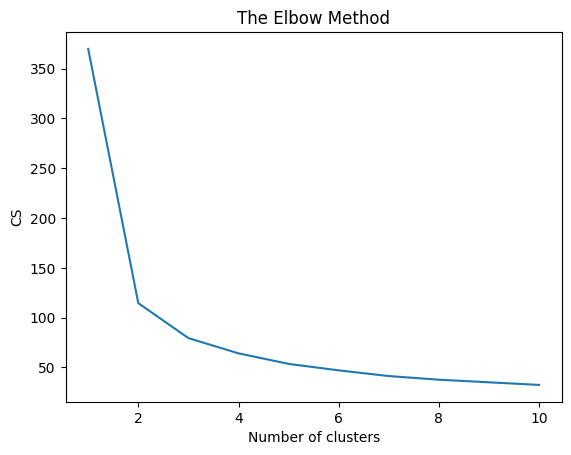

In [845]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [846]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 2010 out of 2556 samples were correctly labeled.
Accuracy score: 0.79


In [847]:
#kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
#kmeans.fit(X_scaled)
#labels = kmeans.labels_
# check how many of the samples were correctly labeled
#correct_labels = sum(y == labels)
#print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
#print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

In [848]:
#kmeans = KMeans(n_clusters=4, n_init = 10,random_state=0)
#kmeans.fit(X_scaled)
#labels = kmeans.labels_
# check how many of the samples were correctly labeled
#correct_labels = sum(y == labels)
#print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
#print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

In [849]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)

In [850]:
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [851]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [852]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [853]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,1.327222,0.250186,1
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,1.331247,0.261891,1
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,1.287679,0.155455,1
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,0.147262,1.189073,0
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,0.163027,1.275139,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,1.314748,0.231343,1
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,1.168755,0.127186,1
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,1.303420,0.191613,1
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,1.301324,0.199389,1


In [854]:
score_dataset(X, y)

0.8882747433634833


In [855]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI Scores
cloud,0.236263
Centroid_0,0.176329
Centroid_1,0.174636
sunshine,0.173626
humidity,0.131327
cluster,0.098592
dewpoint,0.053162
mintemp,0.019220
maxtemp,0.016942
temparature,0.012990


In [856]:
score_dataset(X, y)

0.8882747433634833


In [857]:
X = X.drop(labels = ("mintemp"), axis=1)
X_test = X_test.drop(labels = ("mintemp"), axis=1)
score_dataset(X, y)

0.8858565948749696


In [858]:
#X = X.drop(labels = ("winddirection"), axis=1)
#X_test = X_test.drop(labels = ("winddirection"), axis=1)
#score_dataset(X, y)

In [859]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ["cloud", "cluster", "Centroid_1", "Centroid_0", "humidity", "sunshine", "temparature"]
Z = X.loc[:, features]

# 1. Initialize and fit StandardScaler on training features (Z)
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z)

# 2. Initialize and fit PCA on scaled training features (Z_scaled)
pca = PCA()
X_pca_transformed = pca.fit_transform(Z_scaled)

# 3. Create DataFrame for transformed training data
component_names = [f"PC{i+1}" for i in range(X_pca_transformed.shape[1])]
X_pca_df = pd.DataFrame(X_pca_transformed, columns=component_names, index=X.index)

# 4. Join X_pca_df to X
X = X.join(X_pca_df)
display(X.head())

# Print loadings (optional, but good for understanding components)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=component_names,
    index=features,
)
print(loadings)

,pressure,maxtemp,temparature,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1017.4,21.2,20.6,19.4,87.0,88.0,1.1,60.0,17.2,1.220366,0.046745,1,-1.927844,-0.208931,0.220996,-0.060798,0.066895,-0.145277,-0.116317
1,1019.5,16.2,16.9,15.4,95.0,91.0,0.0,50.0,21.9,1.299471,0.205359,1,-2.455008,-0.352322,1.327231,-0.263635,-0.044601,0.139524,0.047121
2,1024.1,19.4,16.1,9.3,75.0,47.0,8.3,70.0,18.1,0.089320,1.225342,0,2.955282,-1.689875,1.026957,-0.278586,0.049827,-0.428128,0.056174
3,1013.4,18.1,17.8,16.8,95.0,95.0,0.0,60.0,35.6,1.310871,0.219194,1,-2.508371,-0.183419,1.274674,-0.073944,-0.017827,0.211163,0.062917
4,1021.8,21.3,18.4,9.6,52.0,45.0,3.6,40.0,24.8,0.558025,1.217216,0,2.901287,-2.912253,-1.610472,0.345877,-1.081297,0.327375,-0.099696


                  PC1       PC2       PC3       PC4       PC5       PC6  \
cloud       -0.387527  0.126641  0.127814  0.868767  0.225283  0.106176   
cluster     -0.428408 -0.010942 -0.283214 -0.244384  0.358957 -0.148009   
Centroid_1   0.434589 -0.050341  0.235905  0.094460 -0.092880  0.650490   
Centroid_0  -0.429664 -0.067908 -0.231420 -0.264901  0.147573  0.732850   
humidity    -0.288475  0.496710  0.753301 -0.319029  0.026646 -0.000827   
sunshine     0.426413  0.091043  0.052582 -0.052155  0.878496 -0.008877   
temparature  0.166630  0.849522 -0.473307  0.043888 -0.132396  0.080829   

                  PC7  
cloud        0.025827  
cluster      0.725022  
Centroid_1   0.558803  
Centroid_0  -0.358054  
humidity     0.010403  
sunshine    -0.180457  
temparature  0.023236  


In [860]:
# Use the same scaler and PCA fitted on the training data to transform test data (W)

W = X_test.loc[:, features] # Use the same features as training data

# 1. Transform test features (W) using the scaler fitted on training data
W_scaled = scaler.transform(W)

# 2. Transform scaled test features (W_scaled) using the PCA fitted on training data
X_test_pca_transformed = pca.transform(W_scaled)

# 3. Create DataFrame for transformed test data
component_names = [f"PC{i+1}" for i in range(X_test_pca_transformed.shape[1])]
X_test_pca_df = pd.DataFrame(X_test_pca_transformed, columns=component_names, index=X_test.index)

# 4. Join X_test_pca_df to X_test
X_test = X_test.join(X_test_pca_df)

display(X_test.head())

,pressure,maxtemp,temparature,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1019.5,17.5,15.8,14.9,96.0,99.0,0.0,50.0,24.3,1.327222,0.250186,1,-2.678558,-0.422682,1.579441,0.053026,0.083366,0.267605,0.082015
1,1016.5,17.5,16.5,15.1,97.0,99.0,0.0,50.0,35.3,1.331247,0.261891,1,-2.685542,-0.251122,1.612109,0.019745,0.068230,0.299201,0.095964
2,1023.9,11.2,10.4,8.9,86.0,96.0,0.0,40.0,16.9,1.287679,0.155455,1,-2.477865,-1.903545,1.098675,0.263250,0.154640,-0.011743,-0.031001
3,1022.9,20.6,17.3,9.5,75.0,45.0,7.1,20.0,50.6,0.147262,1.189073,0,2.812249,-1.544930,0.843591,-0.383810,-0.266349,-0.373857,0.034366
4,1022.2,16.1,13.8,4.3,68.0,49.0,9.2,20.0,19.4,0.163027,1.275139,0,3.166988,-2.464244,0.601964,0.023125,0.337896,-0.276233,-0.006348


In [861]:
score_dataset(X, y)

0.8861214892018845


In [862]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

,MI Scores
cloud,0.211000
PC1,0.199796
Centroid_1,0.185908
Centroid_0,0.176494
humidity,0.170366
sunshine,0.137935
cluster,0.130351
PC4,0.088605
PC6,0.049291
temparature,0.048603


In [863]:
%%time
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000 # Increased max_iter to address convergence warnings
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression,
    parameters,
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' +
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


-----
Best parameters {'C': 0.01, 'penalty': 'l2'}
Mean cross-validated accuracy score of the best_estimator: 0.895
-----
CPU times: user 36.5 s, sys: 25.8 ms, total: 36.5 s
Wall time: 36.8 s


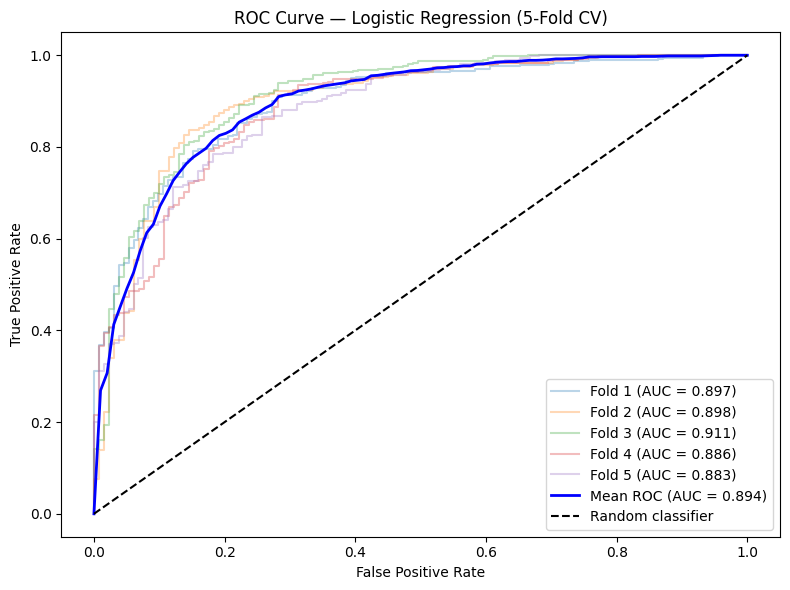

In [864]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

# Create the directory if it doesn't exist
output_dir = "../reports/figures"
os.makedirs(output_dir, exist_ok=True)

model_roc = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

cv = StratifiedKFold(n_splits=5)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(8, 6))

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    model_roc.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = model_roc.predict_proba(X.iloc[val_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y.iloc[val_idx], y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    ax.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold+1} (AUC = {roc_auc:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

ax.plot(mean_fpr, mean_tpr, color="blue", lw=2,
        label=f"Mean ROC (AUC = {mean_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression (5-Fold CV)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [865]:
model_logistic_regression = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)


In [866]:
model_logistic_regression.fit(X, y)
rf_test_preds = model_logistic_regression.predict(X_test)

In [867]:
X_test["id"] = test_data["id"]
X_test["rainfall"] = rf_test_preds
X_test.to_csv('submission_2dts_k-mean_PCA_4_clusters.csv', columns=['id','rainfall'], index=False)

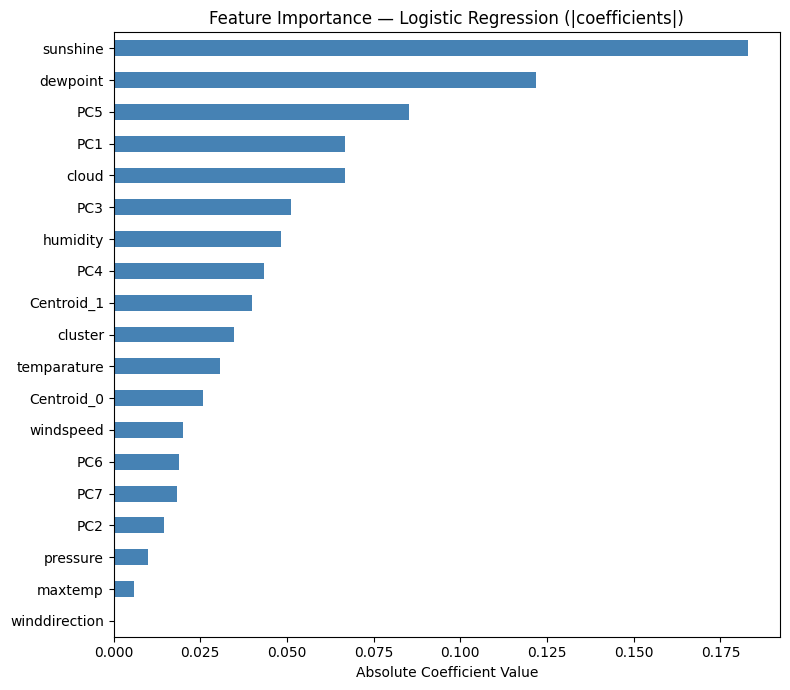

In [868]:
# Fit modelu na všechna data
model_logistic_regression.fit(X, y)

# Koeficienty
coef = pd.Series(
    np.abs(model_logistic_regression.coef_[0]),  # absolutní hodnota = důležitost
    index=X.columns
).sort_values(ascending=True)

# Graf
fig, ax = plt.subplots(figsize=(8, 7))
coef.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance — Logistic Regression (|coefficients|)")
ax.set_xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

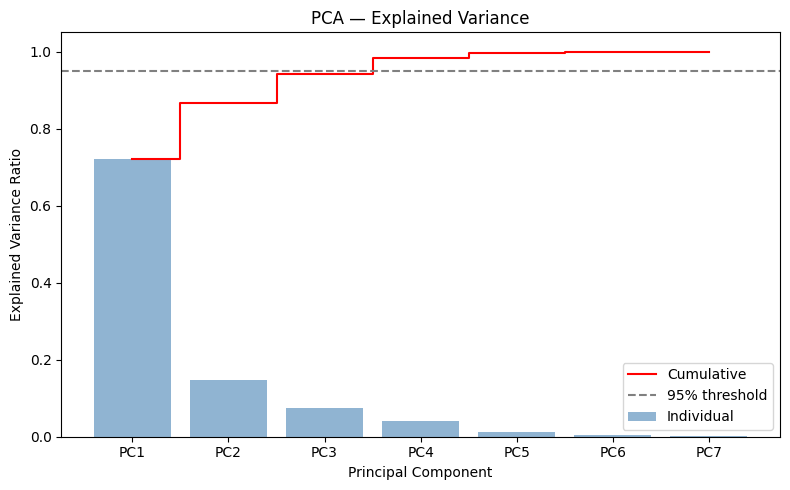

In [869]:
# PCA variance explained
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.6,
       color="steelblue", label="Individual")
ax.step(range(1, len(explained) + 1), cumulative, where="mid",
        color="red", label="Cumulative")
ax.axhline(y=0.95, color="gray", linestyle="--", label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Explained Variance")
ax.set_xticks(range(1, len(explained) + 1))
ax.set_xticklabels([f"PC{i}" for i in range(1, len(explained) + 1)])
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

In [870]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [871]:
google_drive_path = '/content/drive/My Drive/Colab Notebooks/rainfall_prediction_submission.csv'
X_test.to_csv(google_drive_path, columns=['id', 'rainfall'], index=False)
print(f"Predictions saved to: {google_drive_path}")

Predictions saved to: /content/drive/My Drive/Colab Notebooks/rainfall_prediction_submission.csv


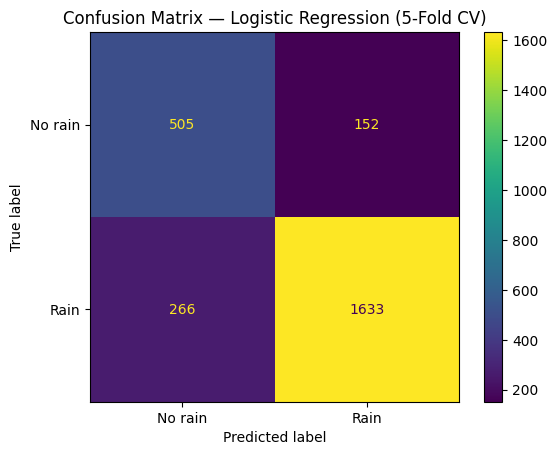

In [872]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model_logistic_regression, X, y, cv=5)
ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=["No rain", "Rain"])
plt.title("Confusion Matrix — Logistic Regression (5-Fold CV)")
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [873]:
import shutil
from google.colab import files
import os

# Define the directory containing the figures
figures_dir = '../reports/figures'

# Create a zip archive of the figures directory
archive_name = 'figures_archive'
shutil.make_archive(archive_name, 'zip', figures_dir)

# Download the zip file
files.download(archive_name + '.zip')

print(f'All figures from "{figures_dir}" have been archived into "{archive_name}.zip" and are ready for download.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All figures from "../reports/figures" have been archived into "figures_archive.zip" and are ready for download.
